## Fraud Detection (Exploratory Data Analysis)

### Dataset Overview

This dataset contains financial transaction records used for detecting fraudulent activities.
It includes transaction amount, transaction type, account balances, and fraud labels.

Objective:
The objective of this analysis is to:
- Understand transaction behavior
- Identify fraudulent transaction patterns
- Analyze transaction types and balances
- Extract business insights using Pandas & Visualization.

### Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.style as style
style.use('ggplot')

### Import Dataset

In [4]:
df = pd.read_csv("C:\\Users\\abhishek\\Downloads\\Fraud Detection.csv")

### Preview the Dataset 

In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


- Dataset contains transaction-related information
- Fraudulent transactions are marked using:
- isFraud
- isFlaggedFraud

### Display Last 10 Rows

In [8]:
df.tail(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.0,C1812552860,0.00,0.00,1,0
6362611,742,CASH_OUT,63416.99,C994950684,63416.99,0.0,C1662241365,276433.18,339850.17,1,0
6362612,743,TRANSFER,1258818.82,C1531301470,1258818.82,0.0,C1470998563,0.00,0.00,1,0
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.0,C1240760502,503464.50,1762283.33,1,0
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.0,C1850423904,0.00,0.00,1,0
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


### Check Dataset Shape

In [7]:
print("Number of Rows ::", df.shape[0])
print("Number of Columns ::", df.shape[1])

Number of Rows :: 6362620
Number of Columns :: 11


### Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


Data types, Non-null values & Memory usage

### Check Missing Values

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Identifies null values before analysis.

### Statistical Summary

In [10]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Mean, Standard deviation, Minimum value, Maximum values & Quartiles.

### Check Transaction Types

In [11]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

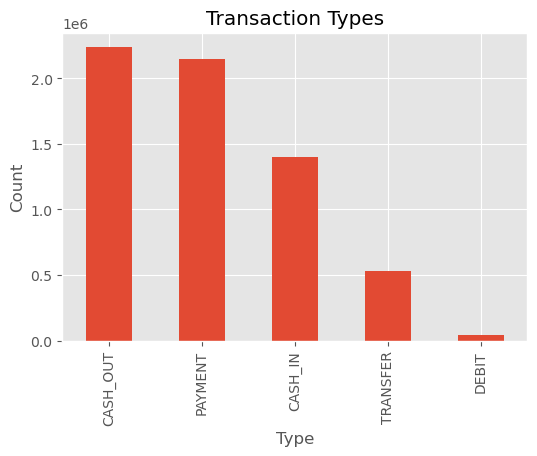

In [14]:
df['type'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Transaction Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Shows the most common transaction categories.

### Total Fraudulent Transactions

In [20]:
fraud_counts = df['isFraud'].value_counts()

summary = pd.DataFrame({
    'Value': fraud_counts.index,
    'Meaning': ['Normal Transaction', 'Fraud Transaction'],
    'Count': fraud_counts.values})
summary

,Value,Meaning,Count
0,0,Normal Transaction,6354407
1,1,Fraud Transaction,8213


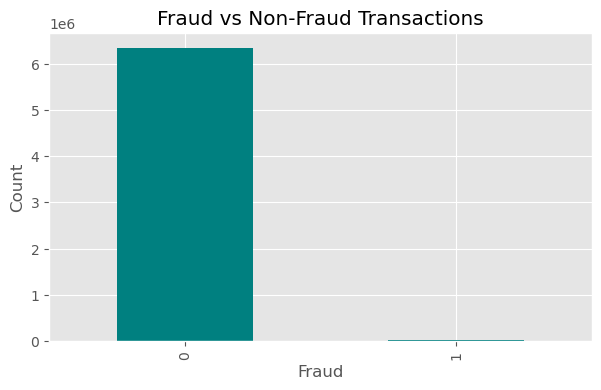

In [25]:
fraud_count = df['isFraud'].value_counts()

fraud_count.plot(kind='bar',figsize=(7,4),color='teal')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

### Percentage of Fraud Transactions

In [23]:
fraud_percentage = (df['isFraud'].sum() / len(df)) * 100

print("Fraud Transaction Percentage ::", round(fraud_percentage,2), "%")

Fraud Transaction Percentage :: 0.13 %


### Highest, Lowest & Average Transaction Amount

In [26]:
print("Highest Transaction Amount ::", df['amount'].max())
print("Lowest Transaction Amount ::", df['amount'].min())
print("Average Transaction Amount ::", round(df['amount'].mean(),2))

Highest Transaction Amount :: 92445516.64
Lowest Transaction Amount :: 0.0
Average Transaction Amount :: 179861.9


### Transaction Amount Distribution

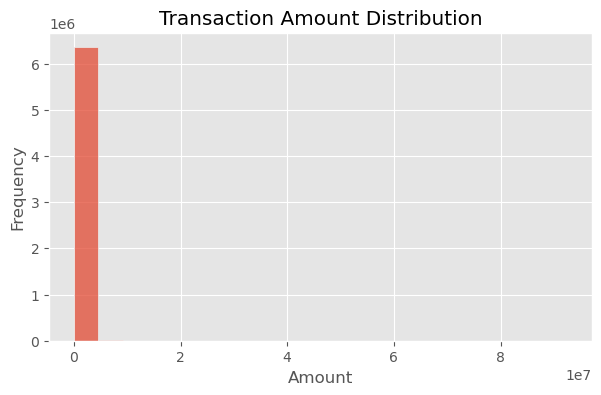

In [28]:
plt.figure(figsize=(7,4))

sns.histplot(df['amount'], bins=20)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

### Which Transaction Types Have Most Fraud?

In [42]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [29]:
df[df['isFraud']==1]['type'].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

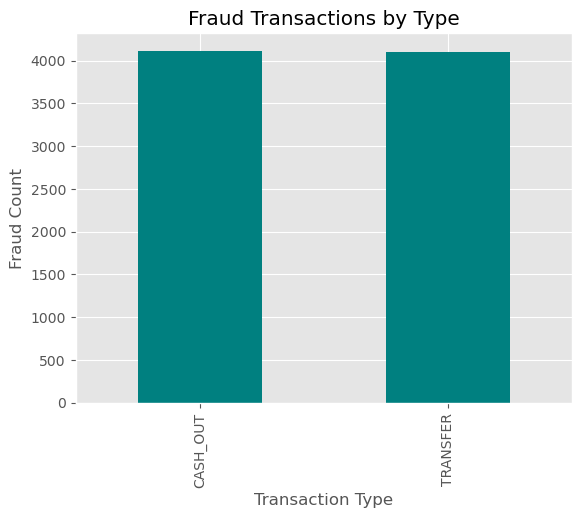

In [31]:
df[df['isFraud']==1]['type'].value_counts().plot(kind='bar',color='teal')

plt.title("Fraud Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Count")

plt.show()

### Top 10 Highest Transaction Amounts

In [32]:
df[['type','amount','isFraud']].sort_values(by='amount', ascending=False).head(10)

,type,amount,isFraud
3686583,TRANSFER,92445516.64,0
4060598,TRANSFER,73823490.36,0
4146397,TRANSFER,71172480.42,0
3946920,TRANSFER,69886731.30,0
3911956,TRANSFER,69337316.27,0
3937152,TRANSFER,67500761.29,0
4105338,TRANSFER,66761272.21,0
3892529,TRANSFER,64234448.19,0
3991638,TRANSFER,63847992.58,0
4143801,TRANSFER,63294839.63,0


### Fraud Transactions Above Average Amount

In [33]:
avg_amount = df['amount'].mean()
df[(df['amount'] > avg_amount) & (df['isFraud']==1)].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
724,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.0,9291619.62,1,0
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.00,1,0
970,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.0,2444985.19,1,0
2301,1,TRANSFER,235238.66,C1872047468,235238.66,0.0,C116289363,0.0,0.00,1,0
2302,1,CASH_OUT,235238.66,C1499825229,235238.66,0.0,C2100440237,0.0,235238.66,1,0


### Sender Balance Before Fraud Transactions

In [35]:
df[df['isFraud']==1]['oldbalanceOrg'].describe()

count    8.213000e+03
mean     1.649668e+06
std      3.547719e+06
min      0.000000e+00
25%      1.258224e+05
50%      4.389835e+05
75%      1.517771e+06
max      5.958504e+07
Name: oldbalanceOrg, dtype: float64

### Compare Fraud vs Non-Fraud Transaction Amounts

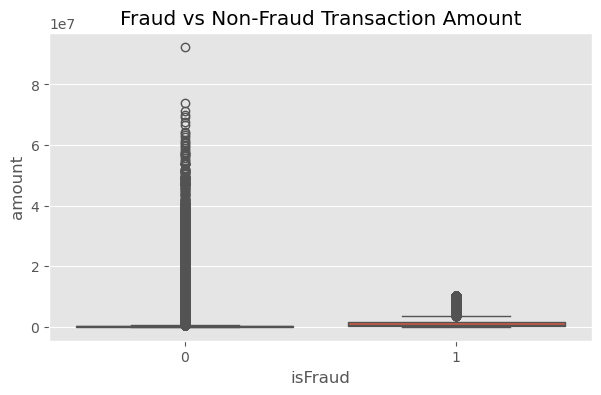

In [36]:
plt.figure(figsize=(7,4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Fraud vs Non-Fraud Transaction Amount")
plt.show()

- 0 = Normal Transaction
- 1 = Fraud Transaction

### Transactions Where Sender Balance Became Zero

In [39]:
df[df['newbalanceOrig']==0].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0
8,1,PAYMENT,4024.36,C1265012928,2671.0,0.0,M1176932104,0.0,0.00,0,0
10,1,DEBIT,9644.94,C1900366749,4465.0,0.0,C997608398,10845.0,157982.12,0,0
13,1,PAYMENT,11633.76,C1716932897,10127.0,0.0,M801569151,0.0,0.00,0,0


### Top 5 Transaction Types by Average Amount

In [38]:
df.groupby('type')['amount'].mean().sort_values(ascending=False).head()

type
TRANSFER    910647.009645
CASH_OUT    176273.964346
CASH_IN     168920.242004
PAYMENT      13057.604660
DEBIT         5483.665314
Name: amount, dtype: float64

### Fraudulent Cash-Out Transactions

In [40]:
df[(df['type']=='CASH_OUT') & (df['isFraud']==1)].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.0,0.00,1,0
681,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.0,12145.85,1,0
724,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.0,9291619.62,1,0
970,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.0,2444985.19,1,0


### Compare fraud count across transaction types

In [48]:
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


### Find transactions with unusually high amounts

In [49]:
threshold = df['amount'].quantile(0.99)
df[df['amount'] > threshold]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
94,1,TRANSFER,1724887.05,C1495608502,0.00,0.0,C1590550415,3470595.10,19169204.93,0,0
359,1,TRANSFER,2421578.09,C106297322,0.00,0.0,C1590550415,8515645.77,19169204.93,0,0
375,1,TRANSFER,2545478.01,C1057507014,0.00,0.0,C1590550415,12394437.40,19169204.93,0,0
376,1,TRANSFER,2061082.82,C2007599722,0.00,0.0,C1590550415,14939915.42,19169204.93,0,0
797,1,TRANSFER,1867849.02,C355885103,0.00,0.0,C665576141,2271538.11,5515763.34,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362599,742,CASH_OUT,4009058.39,C1970706589,4009058.39,0.0,C637394241,1229761.96,5238820.34,1,0
6362602,742,TRANSFER,1819543.69,C2089752665,1819543.69,0.0,C112833674,0.00,0.00,1,0
6362603,742,CASH_OUT,1819543.69,C1039979813,1819543.69,0.0,C2078394828,0.00,1819543.69,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0


### Fraud transactions during high-value transfers

In [50]:
df[(df['amount'] > 200000) & (df['isFraud']==1)]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
724,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.00,9291619.62,1,0
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.00,0.00,1,0
970,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.00,2444985.19,1,0
2301,1,TRANSFER,235238.66,C1872047468,235238.66,0.0,C116289363,0.00,0.00,1,0
2302,1,CASH_OUT,235238.66,C1499825229,235238.66,0.0,C2100440237,0.00,235238.66,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0


### Transaction Amount vs Old Sender Balance

C:\ProgramData\anaconda33\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


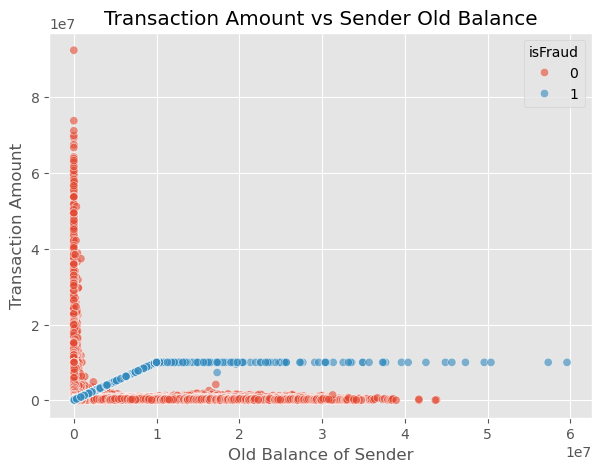

In [12]:
sample_df = df.sample(5000)
plt.figure(figsize=(7,5))
sns.scatterplot(x='oldbalanceOrg', y='amount',hue='isFraud', data=df,alpha=0.6)
plt.title("Transaction Amount vs Sender Old Balance")
plt.xlabel("Old Balance of Sender")
plt.ylabel("Transaction Amount")
plt.show()

### Find duplicate transactions

In [ ]:
int(df.duplicated().sum())

### Which balances strongly correlate with fraud?

In [ ]:
df.corr(numeric_only=True)['isFraud'].sort_values(ascending=False)

Transaction amount has the strongest positive correlation with fraud among balance-related features.

### Correlation Heatmap

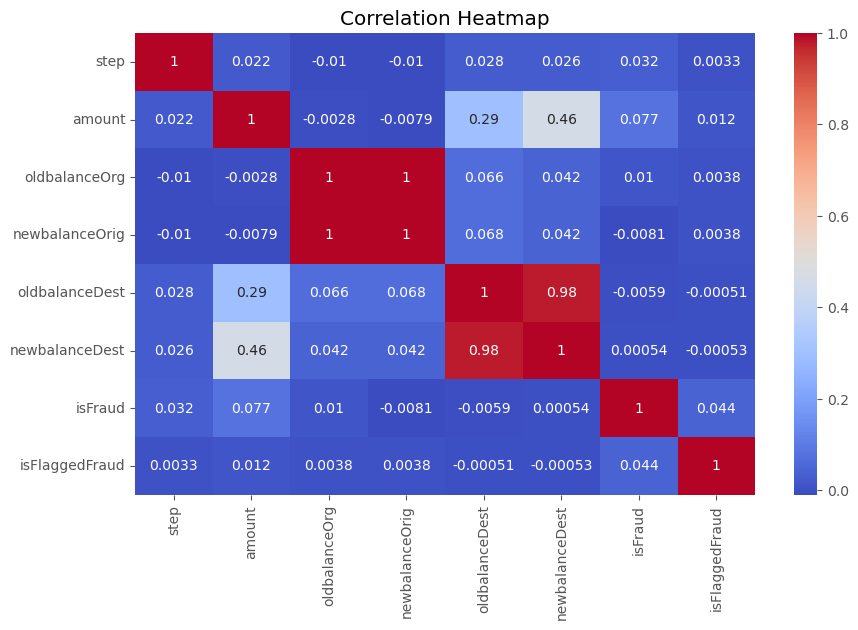

In [55]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Conclusion :-
This analysis explored transaction patterns, customer balances, and fraudulent activities within the financial dataset.

Key Findings
- The dataset contains a very small percentage of fraudulent transactions compared to genuine transactions, making it a highly imbalanced dataset.
- Transaction types such as TRANSFER and CASH_OUT were more commonly associated with fraud activities.
- Fraudulent transactions generally involved unusually high transaction amounts.
- Balance-related features showed suspicious behavior in fraud cases, especially where sender balances became zero after transactions.
- Correlation analysis indicated that transaction amount had the strongest relationship with fraud among numerical features.
- Visualization techniques like count plots, histograms, boxplots, and heatmaps helped identify hidden transaction patterns and anomalies.